In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Large Policy Network

In [10]:
a100l = np.array([31174.53479,
        31256.96495,
        31246.00079,
        31254.84405,
        31292.52974,
        31249.23326])

a100 = np.array([30536.69516,
        30594.55261,
        30639.22733,
        30523.59904,
        30587.33641,
        30583.244])

a6000 = np.array([18131.99124,
        18135.80376,
        18123.8515,
        18141.1521,
        18142.68126,
        18140.10831])

v100 = np.array([12059.1957,
        12130.09281,
        12135.80415,
        12051.11954,
        12071.31014,
        12060.93096])

rtx8000 = np.array([9369.772099,
        10076.45714,
        10509.99457,
        9886.565533,
        9236.879331,
        11916.01286])

l40s = np.array([31169.1991,
        31178.66666,
        31218.68436,
        31195.50373,
        31220.11137,
        31248.67529])

metrics = [l40s, a100, a6000, v100, rtx8000]
gpu_names = ["L40S", "A100", "A6000", "V100", "RTX8000"]

### Small Policy Network

In [5]:
a100l = np.array([
    33131.1056,
    33179.40246,
    33124.02992,
    33205.04755,
    33039.55026,
    33099.21251])

rtx8000 = np.array([
    13147.66227,
    13147.27569,
    13146.72099,
    13139.57018,
    13129.85356,
    13155.43832])

v100 = np.array([
    13884.91617,
    13889.96554,
    13892.97748,
    13882.24301,
    13896.92981,
    13896.26959])

l40s = np.array([
    32598.71005,
    32574.6837,
    32594.74557,
    32565.52841,
    32610.95081,
    32597.01744])

a100 = np.array([
    31774.514,
    31798.01956,
    31776.38622,
    31768.50696,
    31791.21824,
    31797.23824])

h100 = np.array([
    51585.33075,
    51618.7463,
    51575.88474,
    51624.74827,
    51633.74663,
    51658.47338])

a6000 = np.array([
    19054.94207,
    19073.77291,
    19072.72797,
    19080.60751,
    19048.97692,
    19000.82909,
])

metrics = [h100, l40s, a100, a6000, v100, rtx8000]
gpu_names = ["H100", "L40S", "A100", "A6000", "V100", "RTX8000"]

In [3]:
def plot_metrics(arrays, labels, title, ylabel, figsize=(10, 6), 
                colors=None, title_fontsize=14, axis_label_fontsize=12, 
                tick_fontsize=10, text_fontsize=10):
    """
        Parameters:
        - arrays: list of numpy arrays
        - labels: list of strings for x-axis labels (same order as arrays)
        - title: plot title
        - ylabel: y-axis label
        - figsize: figure size tuple
        - colors: list of colors for bars (if None, uses default color cycle)
        - title_fontsize: font size for title
        - axis_label_fontsize: font size for x and y axis labels
        - tick_fontsize: font size for tick marks and labels
    """
    # Calculate means and standard deviations
    means = [np.mean(arr) for arr in arrays]
    stds = [np.std(arr) for arr in arrays]
    
    # Default colors if none provided
    if colors is None:
        colors = ['skyblue', 'lightcoral', 'lightgreen', 'orange', 'plum', 'gold']
    
    # Ensure we have enough colors
    colors = colors * (len(arrays) // len(colors) + 1)

    # Create the bar plot
    plt.figure(figsize=figsize)
    bars = plt.bar(labels, means, yerr=stds, capsize=5, alpha=0.7, 
                   color=colors[:len(arrays)], edgecolor='black', linewidth=1)

    # Add labels and title with font sizes
    plt.xlabel('GPU Models', fontsize=axis_label_fontsize)
    plt.ylabel(ylabel, fontsize=axis_label_fontsize)
    plt.title(title, fontsize=title_fontsize)

    # Format y-axis to use scientific notation with LaTeX formatting
    plt.ticklabel_format(style='scientific', axis='y', scilimits=(0,0), useMathText=True)
    plt.gca().yaxis.get_offset_text().set_fontsize(tick_fontsize)
    
    # Set tick font sizes
    plt.xticks(rotation=45, ha='right', fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Add text above bars showing days to 5B steps
    for i, (bar, mean) in enumerate(zip(bars, means)):
        height = bar.get_height()
        days_to_5b = (5e9 / mean) / (24 * 3600)  # Convert seconds to days
        plt.text(bar.get_x() + bar.get_width()/2., height + stds[i] + height*0.02,
                f'{days_to_5b:.1f} days\nto 5B steps', 
                ha='center', va='bottom', fontsize=text_fontsize, weight='bold')
        
    # Add padding above bars to make room for text
    ax = plt.gca()
    y_min, y_max = ax.get_ylim()
    padding = (y_max - y_min) * 0.15  # Add 15% padding above
    ax.set_ylim(y_min, y_max + padding)

    # Improve layout and show
    plt.tight_layout()

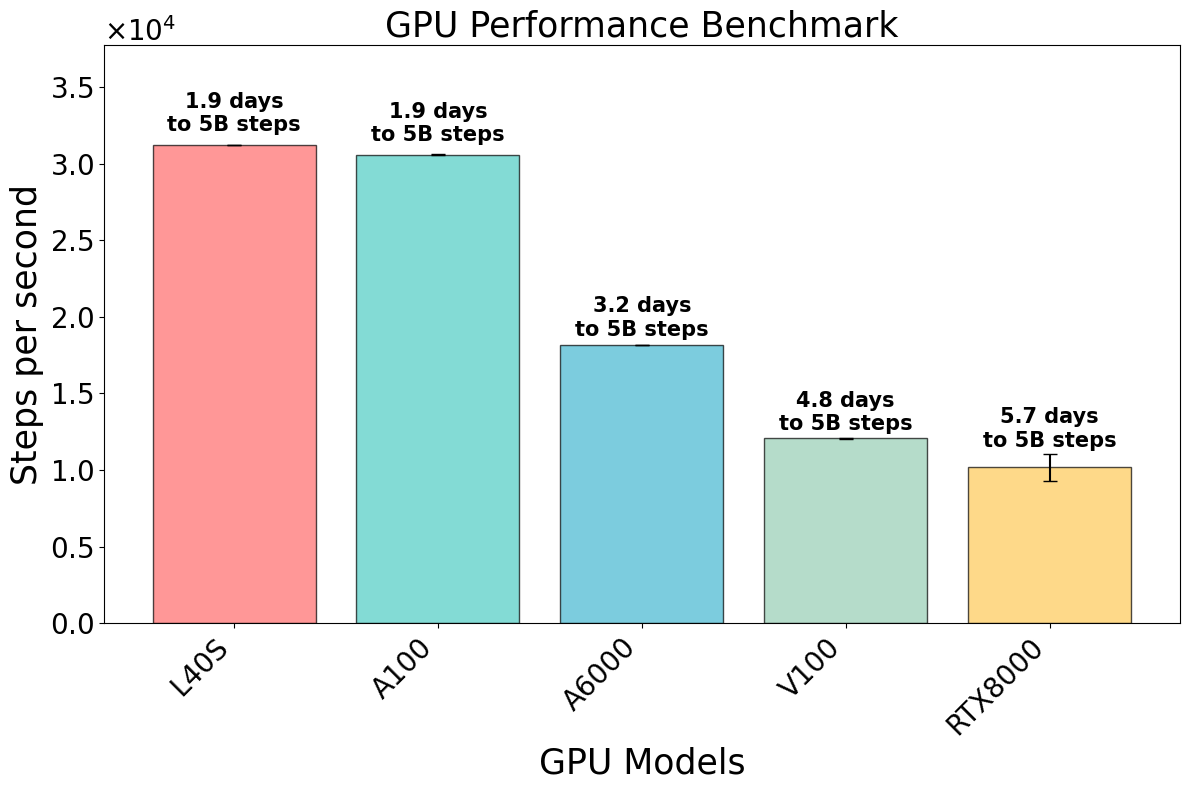

In [11]:
plot_metrics(
    arrays=metrics, 
    labels=gpu_names, 
    title="GPU Performance Benchmark", 
    ylabel="Steps per second", 
    figsize=(12, 8),
    colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3'],
    title_fontsize=25,
    axis_label_fontsize=25,
    tick_fontsize=20,
    text_fontsize=15
)

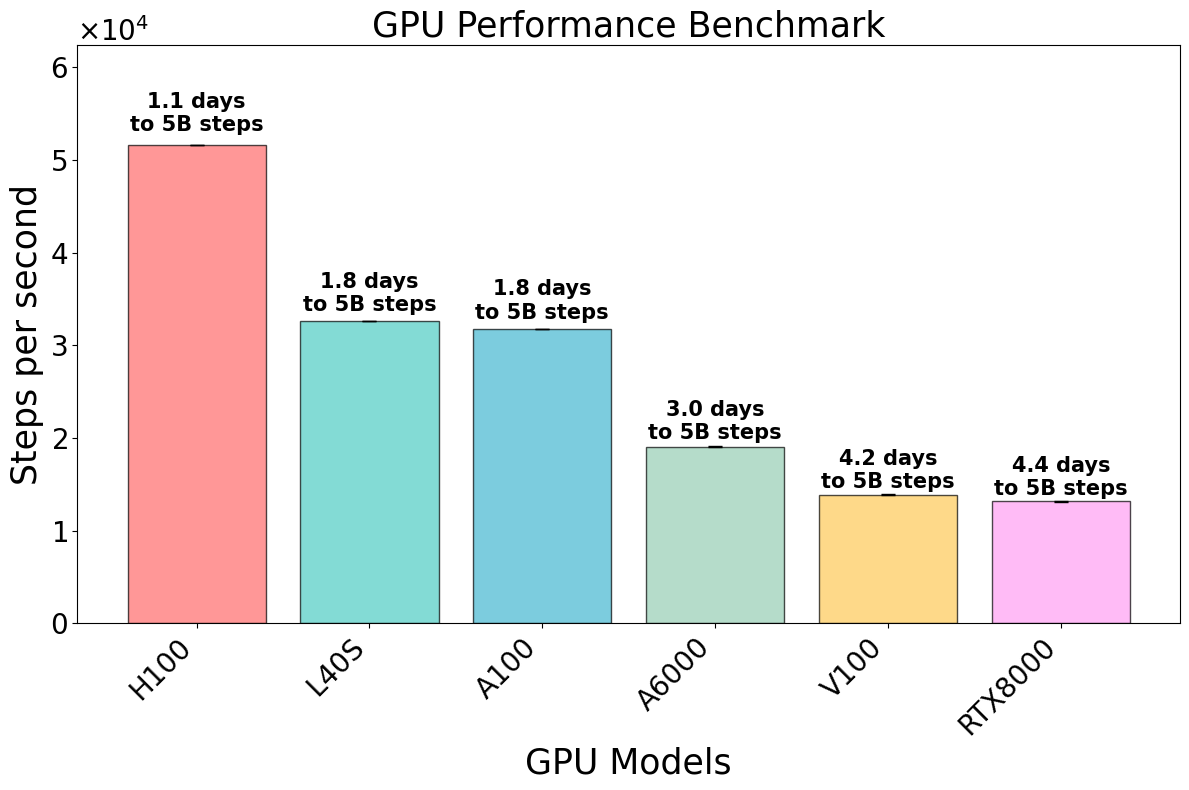

In [6]:
plot_metrics(
    arrays=metrics, 
    labels=gpu_names, 
    title="GPU Performance Benchmark", 
    ylabel="Steps per second", 
    figsize=(12, 8),
    colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3'],
    title_fontsize=25,
    axis_label_fontsize=25,
    tick_fontsize=20,
    text_fontsize=15
)